# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [71]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [72]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Double check some datatypes, and for nulls and duplicates:

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [76]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [77]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [78]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [79]:
df.rename(columns={"Segment":"Customer_Category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Customer_Category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

In [80]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Customer_Category', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


## 3) Build Relational Tables

In [81]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','Customer_Category','City','State','Region', 'Postal Code']] \
    .drop_duplicates() \
    .rename(columns={
        'Customer ID':'customer_id',
        'Customer Name':'customer_name',
        'Customer_Category':'customer_category',
        'City':'city',
        'State':'state',
        'Region':'region',
        'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']] \
    .drop_duplicates() \
    .rename(columns={
        'Product ID':'product_id',
        'Category':'category',
        'Sub-Category':'subcategory',
        'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']] \
    .drop_duplicates() \
    .rename(columns={
        'Order ID':'order_id',
        'Order Date':'order_date',
        'Ship Date':'ship_date',
        'Ship Mode':'ship_mode',
        'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']] \
    .rename(columns={
        'Order ID':'order_id',
        'Product ID':'product_id',
        'Sales':'sales',
        'Quantity':'quantity',
        'Discount':'discount',
        'Profit':'profit'
})

customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')

conn.commit()

In [82]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [83]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
INNER JOIN orders o ON od.order_id = o.order_id
INNER JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [84]:
query2 = """ SELECT 
    c.customer_name, 
    SUM(od.sales) AS total_sales
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
INNER JOIN order_details od ON o.order_id = od.order_id
GROUP BY c.customer_id, c.customer_name
ORDER BY total_sales DESC
LIMIT 10;
 """
result2 = pd.read_sql(query2, conn)
result2

,customer_name,total_sales
0,Ken Lonsdale,155927.519
1,Sanjit Engle,134303.818
2,Clay Ludtke,130566.552
3,Adrian Barton,130262.139
4,Sanjit Chand,127281.006
5,Sean Miller,125215.250
6,Edward Hooks,123730.560
7,Greg Tran,118201.200
8,Seth Vernon,114709.500
9,John Lee,107799.153


### Which product categories and subcategories are the most profitable overall?

In [85]:
query3 = """ SELECT 
    p.category, 
    p.subcategory,
    SUM(od.profit) AS total_profit
FROM products p
INNER JOIN order_details od ON p.product_id = od.product_id
GROUP BY p.category, p.subcategory
ORDER BY total_profit DESC
LIMIT 5;
 """
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,total_profit
0,Technology,Copiers,55617.8249
1,Technology,Accessories,48359.0527
2,Technology,Phones,46936.1861
3,Office Supplies,Paper,36994.5335
4,Office Supplies,Binders,30373.2020


### What is the average discount given per category?

In [86]:
query4 = """ SELECT
    p.category,
    AVG(od.discount) AS discount
FROM products p
INNER JOIN order_details od ON p.product_id = od.product_id
GROUP BY p.category   
      """
result4 = pd.read_sql(query4, conn)
result4

,category,discount
0,Furniture,0.172514
1,Office Supplies,0.157000
2,Technology,0.132970


### Which states or regions contribute the most to total sales?

In [87]:
query5 = """
SELECT
    c.state,
    c.region,
    SUM(od.sales) AS total_sales
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
INNER JOIN order_details od ON TRIM(o.order_id) = TRIM(od.order_id)
GROUP BY c.state, c.region
ORDER BY total_sales DESC
LIMIT 10;
"""
result5 = pd.read_sql(query5, conn)
result5

,state,region,total_sales
0,California,West,3.314838e+06
1,New York,East,1.859365e+06
2,Texas,Central,1.547926e+06
3,Pennsylvania,East,8.861057e+05
4,Washington,West,8.622987e+05
5,Illinois,Central,8.433528e+05
6,Ohio,East,7.077477e+05
7,Florida,South,6.356378e+05
8,North Carolina,South,4.379384e+05
9,Michigan,Central,4.324280e+05


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [88]:
query6 = query_count = """ 
SELECT COUNT(*) as late_order_count
FROM orders 
WHERE (julianday(ship_date) - julianday(order_date)) > 3;
"""
result6 = pd.read_sql(query6, conn)
result6

,late_order_count
0,3391


### Which month or year had the highest total sales?

In [89]:
query7 = """
SELECT 
    strftime('%Y-%m', o.order_date) AS month_year,
    SUM(od.sales) AS total_sales
FROM orders o
INNER JOIN order_details od ON o.order_id = od.order_id
GROUP BY month_year
ORDER BY total_sales DESC;
"""
result7 = pd.read_sql(query7, conn)
result7.head()

,month_year,total_sales
0,2014-11,112326.4710
1,2013-12,97237.4170
2,2014-09,90488.7220
3,2014-12,90474.6008
4,2013-11,82192.3228


### What are the most frequently ordered products?

In [90]:
query8 = """
SELECT 
    p.product_name, 
    COUNT(od.order_id) AS order_count,
    SUM(od.quantity) AS total_units_sold
FROM order_details od
INNER JOIN products p ON od.product_id = p.product_id
GROUP BY p.product_name
ORDER BY order_count DESC
LIMIT 10;
"""
result8 = pd.read_sql(query8, conn)
result8

,product_name,order_count,total_units_sold
0,Staples,227,876
1,Avery Non-Stick Binders,20,71
2,Xerox 1908,19,70
3,Xerox 1881,19,70
4,Logitech P710e Mobile Speakerphone,18,75
5,KI Adjustable-Height Table,18,74
6,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,18,75
7,Storex Dura Pro Binders,17,71
8,"Executive Impressions 13"" Clairmont Wall Clock",16,51
9,"Eldon Image Series Desk Accessories, Burgundy",16,51


### Which customers placed more than 5 orders total?

In [91]:
query9 = """
SELECT 
    c.customer_name, 
    COUNT(o.order_id) AS total_orders
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_name
HAVING total_orders > 5
ORDER BY total_orders DESC
LIMIT 10;
"""
result9 = pd.read_sql(query9, conn)
result9

,customer_name,total_orders
0,Emily Phan,289
1,Zuschuss Carroll,169
2,Sally Hughsby,169
3,Joel Eaton,169
4,Erin Ashbrook,169
5,Patrick Gardner,156
6,Noel Staavos,156
7,Suzanne McNair,144
8,Sanjit Jacobs,144
9,Rick Bensley,144


### What’s the profit margin (profit ÷ sales) by category or segment?

In [92]:
query10 = """
SELECT 
    p.category, 
    c.customer_category,
    SUM(od.profit) AS total_profit, 
    SUM(od.sales) AS total_sales,
    (CAST(SUM(od.profit) AS FLOAT) / SUM(od.sales)) * 100 AS margin_percentage
FROM order_details od
JOIN products p ON od.product_id = p.product_id
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY p.category, c.customer_category
ORDER BY p.category, margin_percentage DESC;
"""
result10 = pd.read_sql(query10, conn)
result10

,category,customer_category,total_profit,total_sales,margin_percentage
0,Furniture,Corporate,59737.0342,1.647140e+06,3.626712
1,Furniture,Home Office,24383.7912,8.610328e+05,2.831924
2,Furniture,Consumer,76983.9810,3.049687e+06,2.524324
3,Office Supplies,Home Office,208675.2812,9.192197e+05,22.701350
4,Office Supplies,Corporate,295830.4917,1.757109e+06,16.836208
5,Office Supplies,Consumer,419514.8788,2.677126e+06,15.670345
6,Technology,Corporate,325555.9750,1.798529e+06,18.101234
7,Technology,Home Office,231782.7514,1.342732e+06,17.262021
8,Technology,Consumer,526444.8580,3.062353e+06,17.190864


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

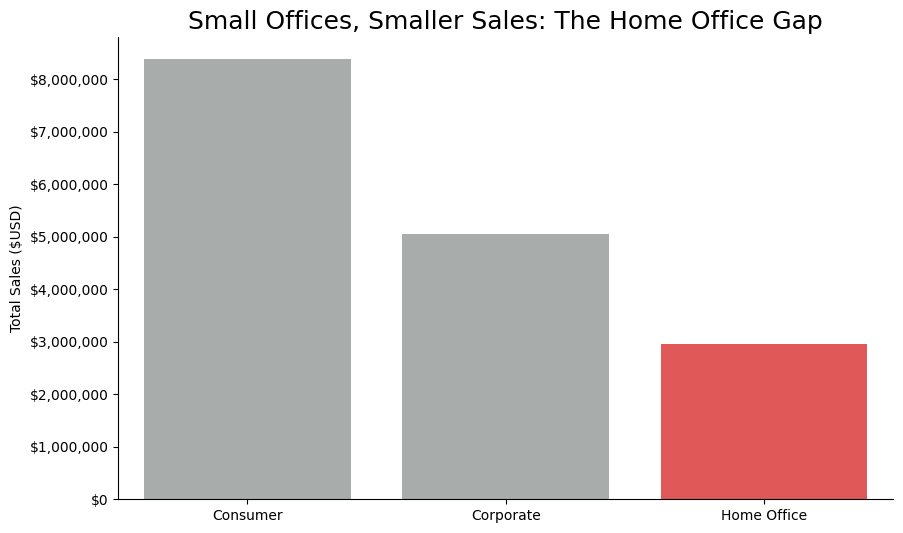

In [93]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


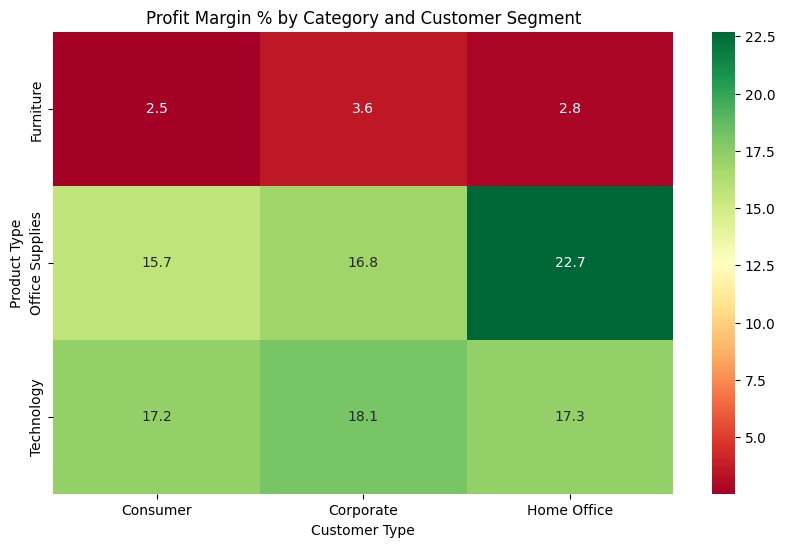

In [94]:
# Investigating Profit Margin % by Category and Customer type

pivot_table = result10.pivot(index='category', columns='customer_category', values='margin_percentage')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', fmt='.1f')
plt.title('Profit Margin % by Category and Customer Segment')
plt.xlabel("Customer Type")  
plt.ylabel("Product Type")      
plt.show()

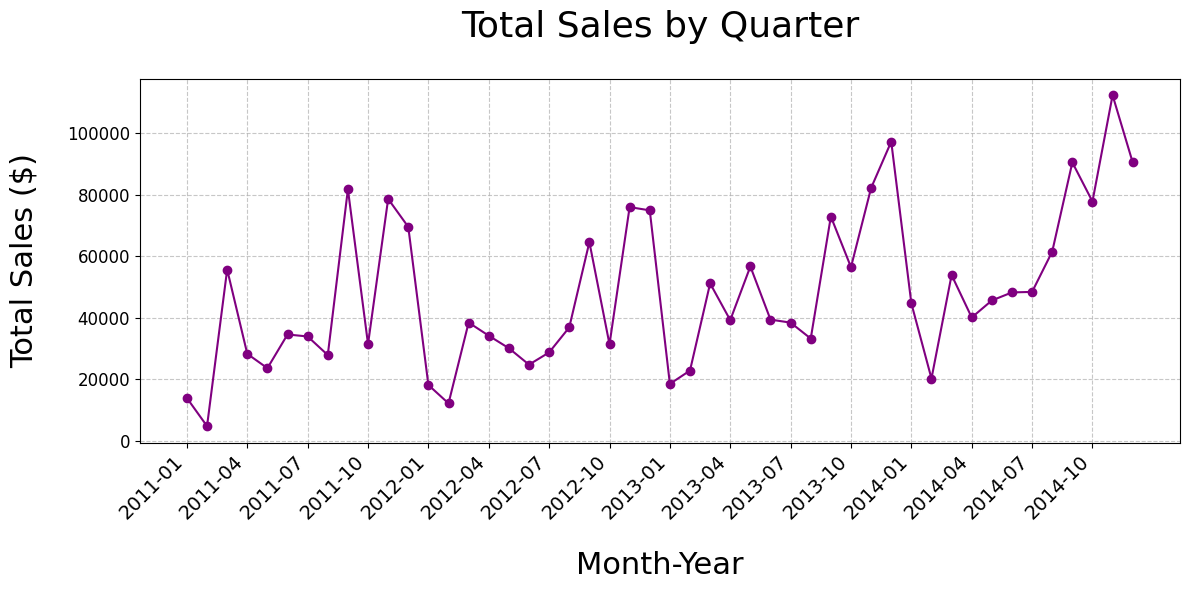

In [95]:
# Line chart showing how the business does over the course of a year

result7= result7.sort_values('month_year')
plt.figure(figsize=(12,6))
plt.plot(result7['month_year'], result7['total_sales'], marker='o', linestyle='-', color='purple')

plt.title('Total Sales by Quarter', fontsize=26, pad=30)
plt.xlabel('Month-Year', fontsize=22, labelpad=20)
plt.ylabel('Total Sales ($)', fontsize=22, labelpad=20)
plt.xticks(ticks=result7['month_year'][::3], rotation=45, fontsize=14, ha='right')
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

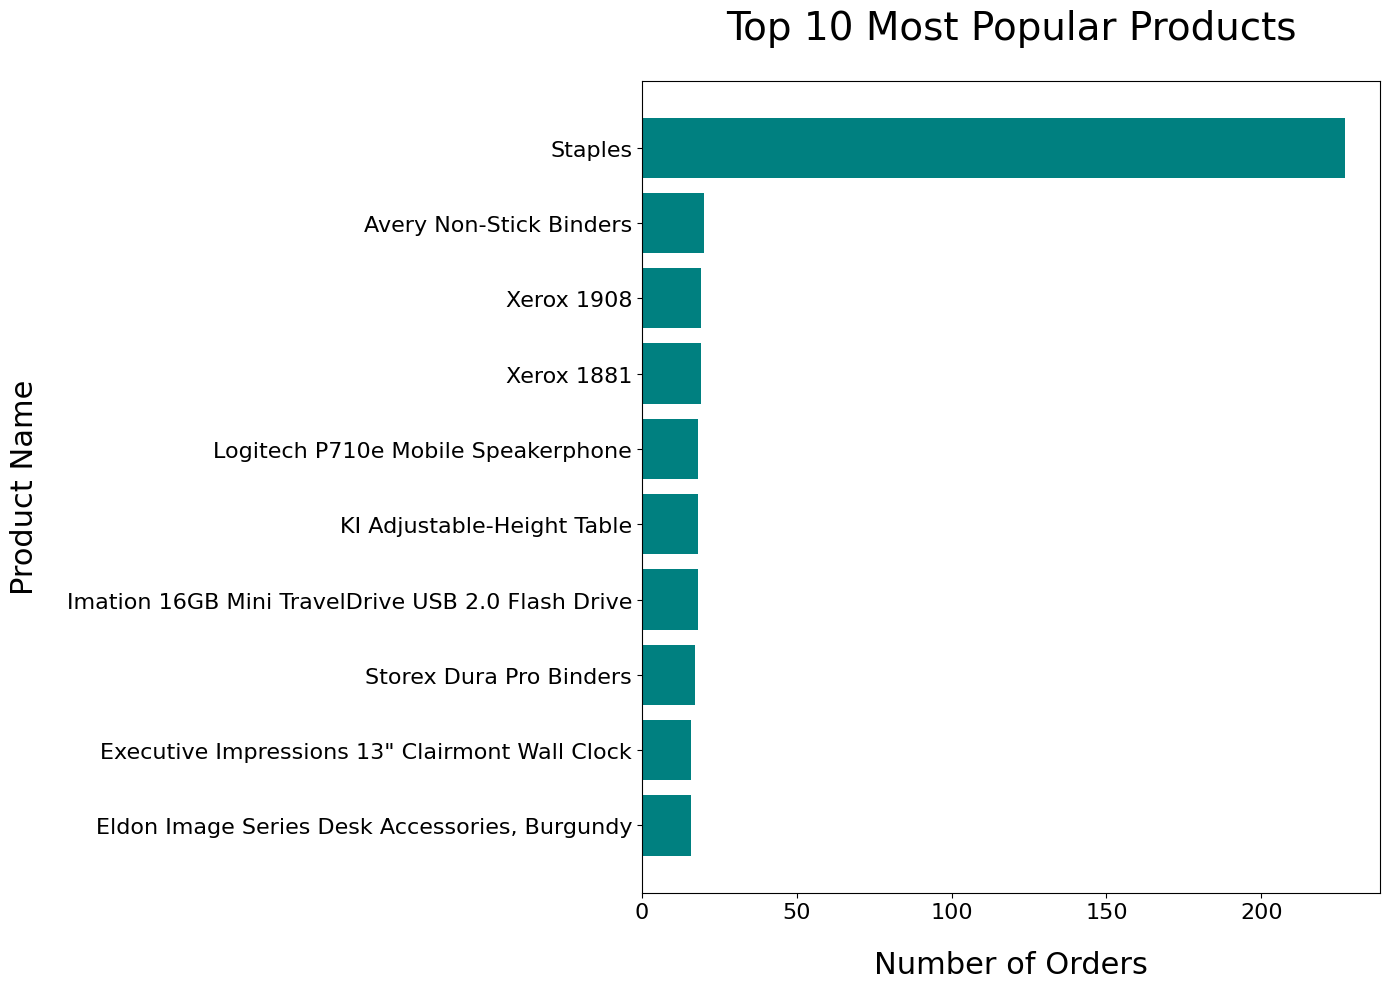

In [96]:
# Looking at most popular products, seems that staples is the bulk of business.

plt.figure(figsize=(14, 10))
plt.barh(result8['product_name'], result8['order_count'], color='teal')

plt.title('Top 10 Most Popular Products', fontsize=28, pad=30)
plt.xlabel('Number of Orders', fontsize=22, labelpad=20)
plt.ylabel('Product Name', fontsize=22, labelpad=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.gca().invert_yaxis() # Chose to put staples at the top to visualize how much more it sells than other products

plt.tight_layout()
plt.show()

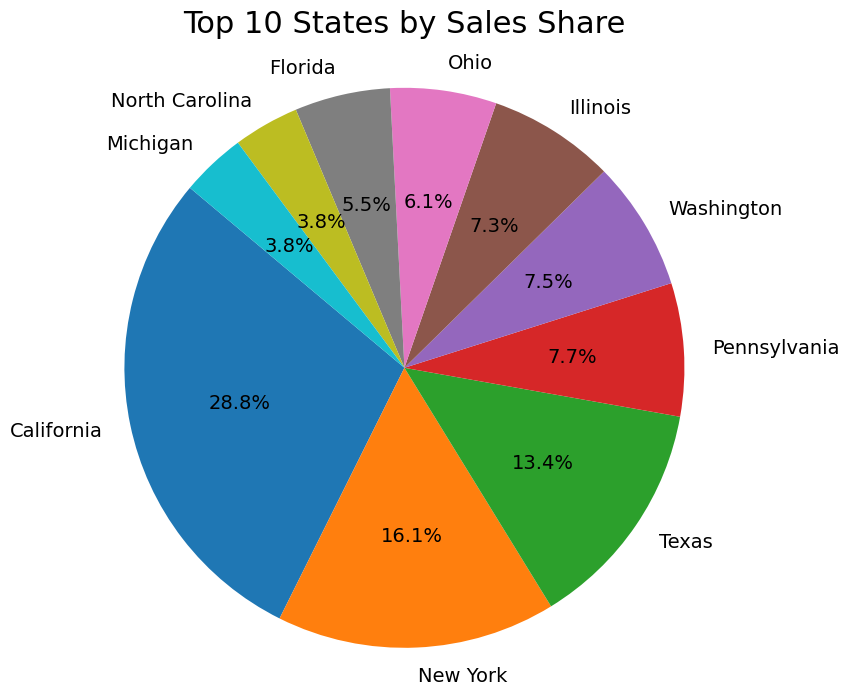

In [97]:
# Looking at most popular states, which appears to be California.
plt.figure(figsize=(10, 8))

plt.pie(result5['total_sales'], 
        labels=result5['state'], 
        autopct='%1.1f%%', 
        startangle=140,
        textprops={'fontsize': 14})

plt.title('Top 10 States by Sales Share', fontsize=22, pad=20)
plt.axis('equal') 
plt.show()